In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Mall_Customers (1).csv to Mall_Customers (1).csv


In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv("Mall_Customers (1).csv")

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [ ]:
df.shape

(200, 5)

In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.index

RangeIndex(start=0, stop=200, step=1)

In [ ]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
195,False,False,False,False,False
196,False,False,False,False,False
197,False,False,False,False,False
198,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.notnull()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,True,True,True,True,True
1,True,True,True,True,True
2,True,True,True,True,True
3,True,True,True,True,True
4,True,True,True,True,True
...,...,...,...,...,...
195,True,True,True,True,True
196,True,True,True,True,True
197,True,True,True,True,True
198,True,True,True,True,True


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
195,False
196,False
197,False
198,False


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
CustomerID,200
Gender,2
Age,51
Annual Income (k$),64
Spending Score (1-100),84


In [ ]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

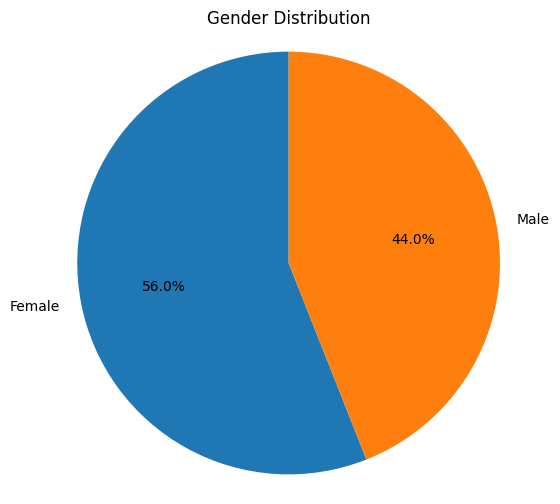

In [ ]:
import matplotlib.pyplot as plt
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Gender Distribution")
plt.axis('equal')
plt.show()

In [ ]:
import plotly.express as px
fig=px.pie(
    df,
    names='Gender',
    title='Gender Distribution',
    hole=0.4,
    width=800,
    height=600
)
fig.show()


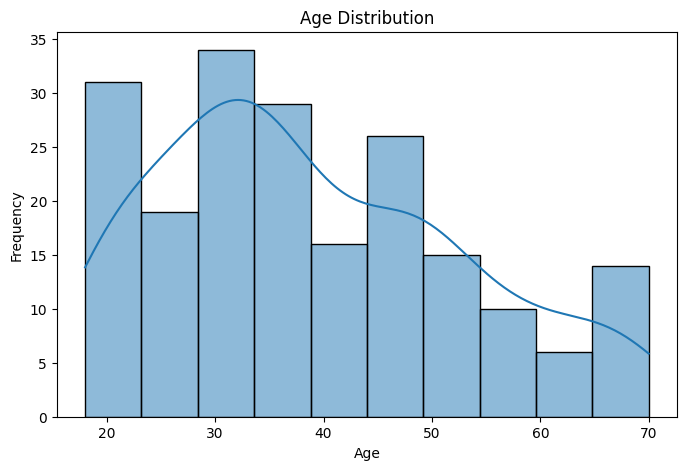

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=10, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [ ]:
import plotly.express as px

fig = px.histogram(
    df,
    x='Age',
    nbins=10,
    title='Age Distribution',
    marginal='box',
    width=800,
    height=600
)

fig.show()

In [ ]:
import plotly.figure_factory as ff

fig = ff.create_distplot(
    [df['Age']],
    group_labels=['Age'],
    show_hist=True,
    show_rug=False
)

fig.update_layout(title='Age Distribution with KDE')

fig.show()

In [ ]:
import plotly.express as px

fig = px.histogram(
    df,
    x='Annual Income (k$)',
    nbins=20,
    title='Annual Income Distribution',
    labels={'Annual Income (k$)': 'Annual Income'}
)

fig.update_layout(
    xaxis_title='Annual Income (k$)',
    yaxis_title='Frequency',
    bargap=0.05
)

fig.show()

In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x='Age',
    y='Spending Score (1-100)',
    title='Age vs Spending Score',
    labels={
        'Age': 'Age',
        'Spending Score (1-100)': 'Spending Score'
    },
    opacity=0.7
)
fig.update_traces(marker=dict(size=10))

fig.update_layout(
    xaxis_title='Age',
    yaxis_title='Spending Score'
)

fig.show()

In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    title='Annual Income vs Spending Score',
    labels={
        'Annual Income (k$)': 'Annual Income (k$)',
        'Spending Score (1-100)': 'Spending Score'
    },
    opacity=0.7
)

fig.show()


In [ ]:

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [ ]:
df['Gender'].value_counts()

,count
Gender,
0,112
1,88


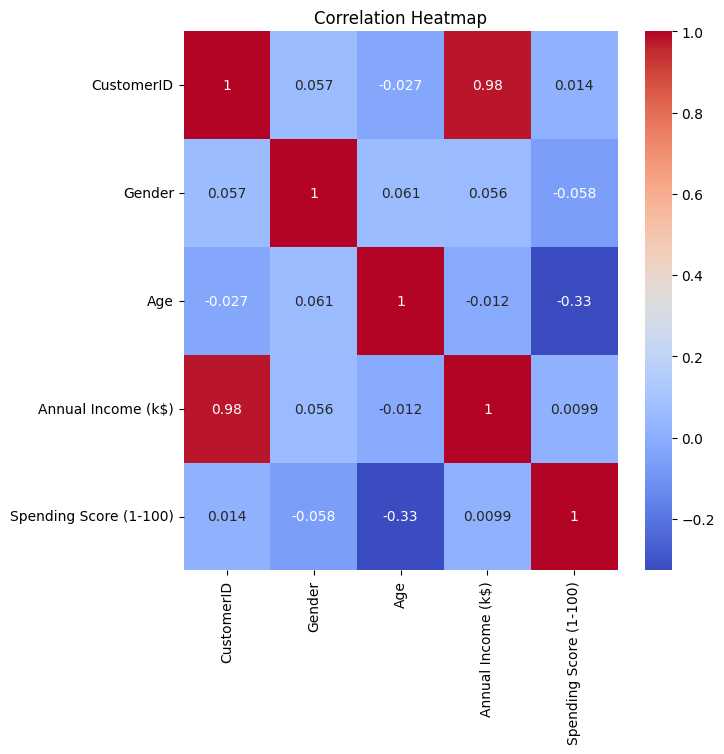

In [ ]:
corr = df.corr()

plt.figure(figsize=(7,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42 ,n_init=10)
df['cluster'] = kmeans.fit_predict(df[['Annual Income (k$)', 'Spending Score (1-100)']])


In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4


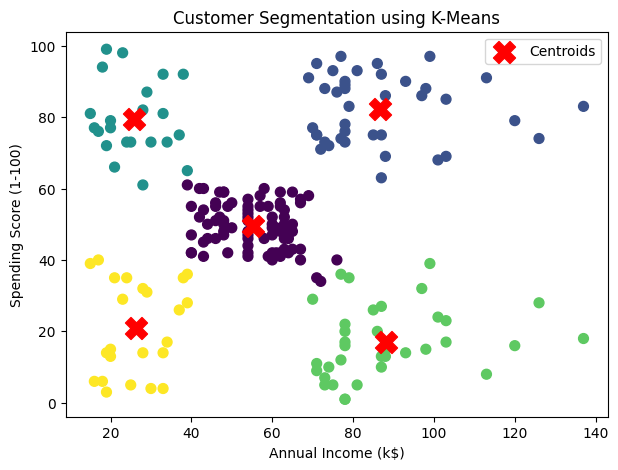

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['cluster'],
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker='X',
    s=250,
    color='red',
    label='Centroids'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Age',
    y='Annual Income (k$)',
    z='Spending Score (1-100)',
    color='Gender',   # Corrected from 'Genre' to 'Gender'
    title='3D Customer Distribution',
    width=900,
    height=700
)

fig.show()